Maszyny wektorów nośnych (SVM) są szczególnie potężną i elastyczną klasą nadzorowanych algorytmów zarówno klasyfikacji, jak i regresji. W tej sekcji rozwiniemy intuicję stojącą za maszynami wektorów nośnych i ich zastosowaniem w problemach klasyfikacji.

Zaczniemy od standardowego importu:

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# use seaborn plotting defaults
import seaborn as sns; sns.set()

W ramach naszej dyskusji na temat klasyfikacji bayesowskiej  nauczyliśmy się prostego modelu opisującego rozkład każdej klasy bazowej i wykorzystaliśmy te modele generatywne do probabilistycznego określenia etykiet dla nowych punktów. Był to przykład klasyfikacji generatywnej; tutaj zamiast tego rozważymy klasyfikację dyskryminacyjną: zamiast modelować każdą klasę, po prostu znajdujemy linię lub krzywą (w dwóch wymiarach) lub rozmaitość (w wielu wymiarach), która oddziela klasy od siebie.

Jako przykład rozważmy prosty przypadek zadania klasyfikacji, w którym dwie klasy punktów są dobrze rozdzielone:

Importujemy funkcję make_blobs z sklearn.datasets, która służy do generowania zbioru danych złożonego z kilku grup punktów (klastrów).
Za pomocą make_blobs generujemy dane:

- n_samples=50 oznacza, że tworzymy 50 próbek.

- centers=2 oznacza, że dane będą miały dwa centra (dwa klastry).

- random_state=0 zapewnia powtarzalność wyników.

- cluster_std=0.60 określa odchylenie standardowe klastrów.

Dane są przechowywane w X (współrzędne punktów) i y (etykiety klastrów).
Tworzymy wykres punktowy za pomocą plt.scatter:
X[:, 0] i X[:, 1] to współrzędne punktów.
c=y koloryzuje punkty na podstawie przynależności do klastrów.
s=50 określa rozmiar punktów.
cmap='autumn' ustawia kolory zgodnie z mapą kolorów 'autumn'.

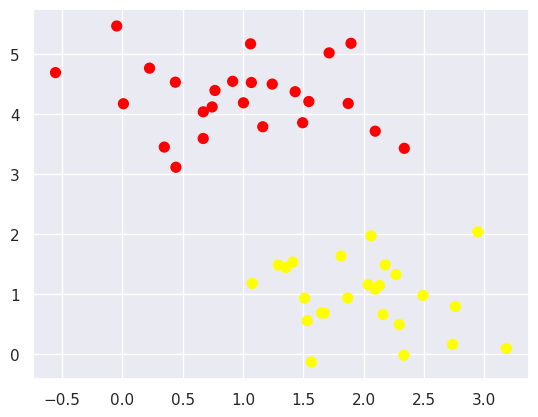

In [ ]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=50, centers=2,
                  random_state=0, cluster_std=0.60)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn');

Liniowy klasyfikator dyskryminacyjny próbowałby narysować linię prostą oddzielającą dwa zestawy danych, a tym samym stworzyć model klasyfikacji. W przypadku danych dwuwymiarowych, takich jak te pokazane tutaj, jest to zadanie, które moglibyśmy wykonać ręcznie. Ale od razu widzimy problem: istnieje więcej niż jedna możliwa linia podziału, która doskonale rozróżnia dwie klasy!

Możemy je narysować w następujący sposób:

- xfit = np.linspace(-1, 3.5) tworzy liniowo rozłożone wartości x od -1 do 3.5.
- plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn') rysuje punkty danych tak jak wcześniej.
- plt.plot([0.6], [2.1], 'x', color='red', markeredgewidth=2, markersize=10) dodaje czerwony punkt w pozycji (0.6, 2.1).
- Następnie pętla for m, b in [(1, 0.65), (0.5, 1.6), (-0.2, 2.9)] rysuje trzy linie:
- Każda linia ma nachylenie m i przesunięcie b.
- plt.plot(xfit, m * xfit + b, '-k') rysuje linię dla każdego zestawu parametrów m i b, z kolorem czarnym ('-k').
- plt.xlim(-1, 3.5) ustawia zakres osi x od -1 do 3.5.



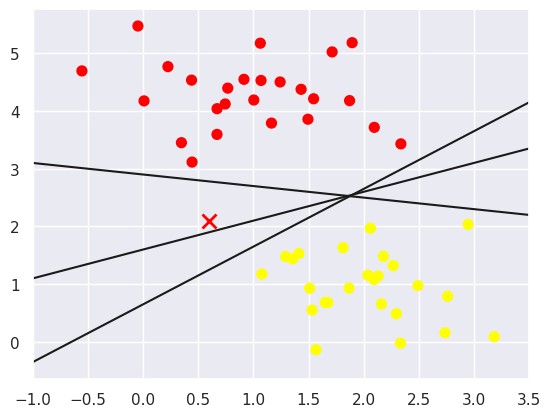

In [ ]:
xfit = np.linspace(-1, 3.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plt.plot([0.6], [2.1], 'x', color='red', markeredgewidth=2, markersize=10)

for m, b in [(1, 0.65), (0.5, 1.6), (-0.2, 2.9)]:
    plt.plot(xfit, m * xfit + b, '-k')

plt.xlim(-1, 3.5);

Są to trzy bardzo różne separatory, które jednak doskonale rozróżniają te próbki. W zależności od tego, który wybierzesz, nowy punkt danych (np. ten oznaczony „X” na tym wykresie) otrzyma inną etykietę! Najwyraźniej nasza prosta intuicja „rysowania linii między klasami” nie wystarcza i musimy pomyśleć nieco głębiej.

Maszyny wektorów nośnych oferują jeden ze sposobów na poprawę tej sytuacji. Intuicja jest następująca: zamiast po prostu rysować linię o zerowej szerokości między klasami, możemy narysować wokół każdej linii margines o pewnej szerokości, do najbliższego punktu. Oto przykład, jak to może wyglądać:



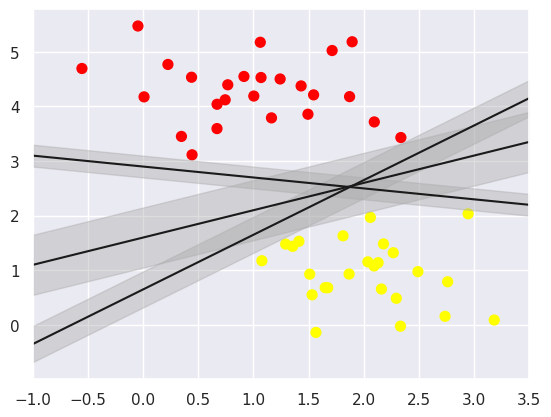

In [ ]:
xfit = np.linspace(-1, 3.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')

for m, b, d in [(1, 0.65, 0.33), (0.5, 1.6, 0.55), (-0.2, 2.9, 0.2)]:
    yfit = m * xfit + b
    plt.plot(xfit, yfit, '-k')
    plt.fill_between(xfit, yfit - d, yfit + d, edgecolor='none',
                     color='#AAAAAA', alpha=0.4)

plt.xlim(-1, 3.5);

W maszynach wektorów nośnych linia, która maksymalizuje ten margines, jest tą, którą wybierzemy jako optymalny model. Maszyny wektorów wspierających są przykładem takiego estymatora maksymalnego marginesu.

Zobaczmy wynik rzeczywistego dopasowania do tych danych: użyjemy klasyfikatora wektorów nośnych Scikit-Learn, aby wytrenować model SVM na tych danych. Na razie użyjemy jądra liniowego i ustawimy parametr C na bardzo dużą liczbę (omówimy ich znaczenie bardziej szczegółowo za chwilę).

In [ ]:
from sklearn.svm import SVC # "Support vector classifier"
model = SVC(kernel='linear', C=1E10)
model.fit(X, y)

SVC(C=10000000000.0, kernel='linear')

Aby lepiej zwizualizować to, co się tutaj dzieje, stwórzmy szybką wygodną funkcję, która wykreśli dla nas granice decyzji SVM:

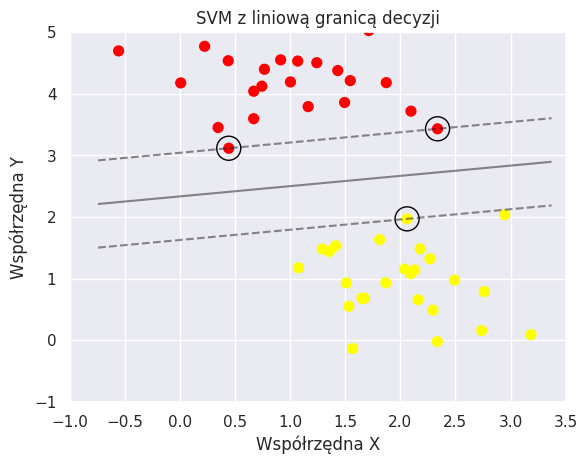

In [ ]:
# Tworzymy dane
X, y = make_blobs(n_samples=50, centers=2, random_state=0, cluster_std=0.60)

# Tworzymy i trenujemy model SVM
model = SVC(kernel='linear', C=1E10)
model.fit(X, y)

# Funkcja do rysowania granicy decyzji
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Rysuje granicę decyzji SVM."""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Tworzymy siatkę do oceny modelu
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # Rysujemy granicę decyzji i marginesy
    ax.contour(X, Y, P, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])

    # Rysujemy wektory nośne
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=300, linewidth=1, facecolors='none', edgecolors='black')

# Rysujemy wykres punktowy danych
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')

# Rysujemy granicę decyzji SVM
plot_svc_decision_function(model)

# Ustawiamy zakres osi x
plt.xlim(-1, 3.5)
plt.ylim(-1, 5)

# Dodajemy etykiety i tytuł
plt.xlabel('Współrzędna X')
plt.ylabel('Współrzędna Y')
plt.title('SVM z liniową granicą decyzji')
plt.show()

Jest to linia podziału, która maksymalizuje margines między dwoma zestawami punktów. Zauważ, że kilka punktów treningowych po prostu dotyka marginesu: są one oznaczone czarnymi kółkami na tym rysunku. Punkty te są kluczowymi elementami tego dopasowania i są znane jako wektory wsparcia i nadają algorytmowi jego nazwę. W Scikit-Learn tożsamość tych punktów jest przechowywana w atrybucie support_vectors_ klasyfikatora:

In [ ]:
model.support_vectors_

array([[0.44359863, 3.11530945],
       [2.33812285, 3.43116792],
       [2.06156753, 1.96918596]])

Kluczem do sukcesu tego klasyfikatora jest to, że dla dopasowania znaczenie ma tylko pozycja wektorów wsparcia; wszelkie punkty znajdujące się dalej od marginesu, które są po właściwej stronie, nie modyfikują dopasowania! Technicznie rzecz biorąc, dzieje się tak dlatego, że punkty te nie przyczyniają się do funkcji straty używanej do dopasowania modelu, więc ich położenie i liczba nie mają znaczenia, o ile nie przekraczają marginesu.

Możemy to zobaczyć na przykład, jeśli wykreślimy model wyuczony z pierwszych 60 punktów i pierwszych 120 punktów tego zestawu danych:

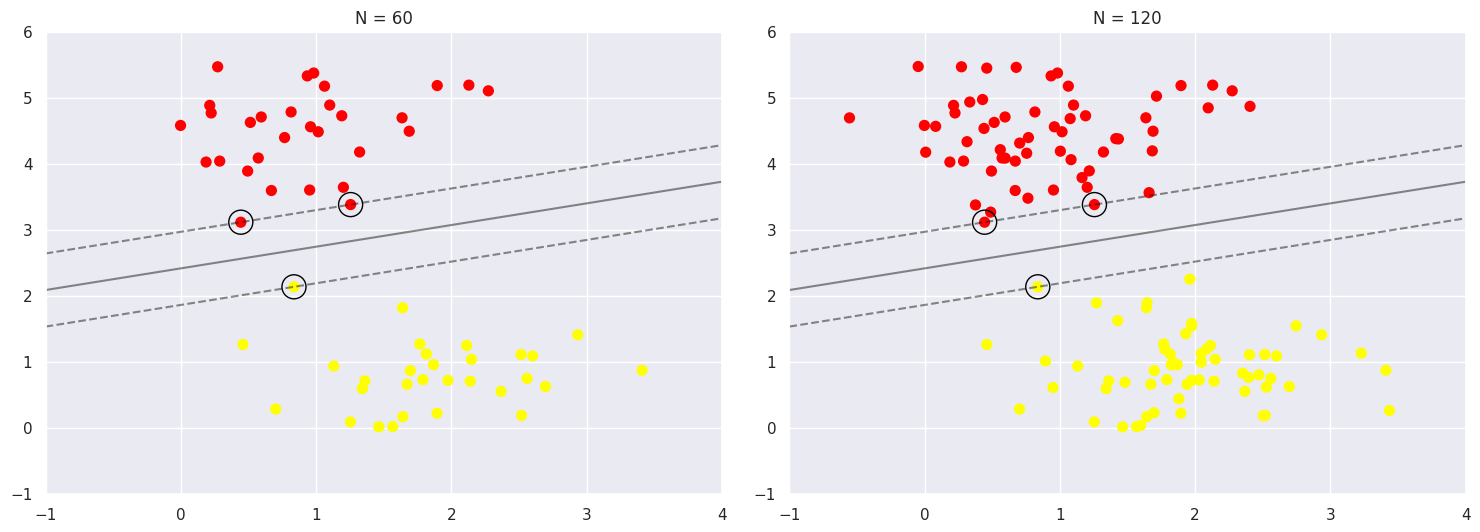

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import SVC

def plot_svm(N=10, ax=None):
    # Generowanie danych
    X, y = make_blobs(n_samples=200, centers=2, random_state=0, cluster_std=0.60)
    X = X[:N]
    y = y[:N]
    # Tworzenie i trenowanie modelu SVM
    model = SVC(kernel='linear', C=1E10)
    model.fit(X, y)

    # Rysowanie punktów danych
    ax = ax or plt.gca()
    ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
    ax.set_xlim(-1, 4)
    ax.set_ylim(-1, 6)
    # Rysowanie granicy decyzyjnej SVM
    plot_svc_decision_function(model, ax)

def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Rysuje granicę decyzji SVM."""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Tworzenie siatki do oceny modelu
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # Rysowanie granicy decyzji i marginesów
    ax.contour(X, Y, P, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])

    # Rysowanie wektorów nośnych
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=300, linewidth=1, facecolors='none', edgecolors='black')

# Tworzenie wykresów
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)
for axi, N in zip(ax, [60, 120]):
    plot_svm(N, axi)
    axi.set_title('N = {0}'.format(N))

plt.show()

W lewym panelu widzimy model i wektory wsparcia dla 60 punktów treningowych. W prawym panelu podwoiliśmy liczbę punktów treningowych, ale model się nie zmienił: trzy wektory wsparcia z lewego panelu są nadal wektorami wsparcia z prawego panelu. Ta niewrażliwość na dokładne zachowanie odległych punktów jest jedną z mocnych stron modelu SVM.

Jeśli korzystasz z tego notatnika na żywo, możesz użyć interaktywnych widżetów IPython, aby interaktywnie wyświetlić tę funkcję modelu SVM:

interactive(children=(Dropdown(description='N', options=(10, 200), value=10), Output()), _dom_classes=('widget…

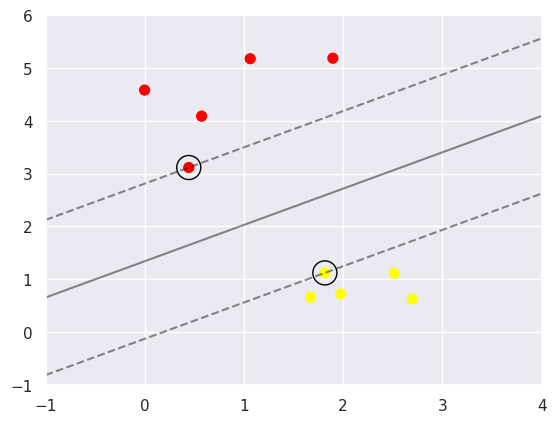

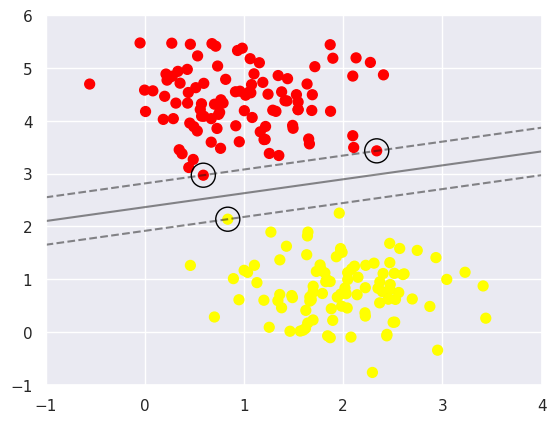

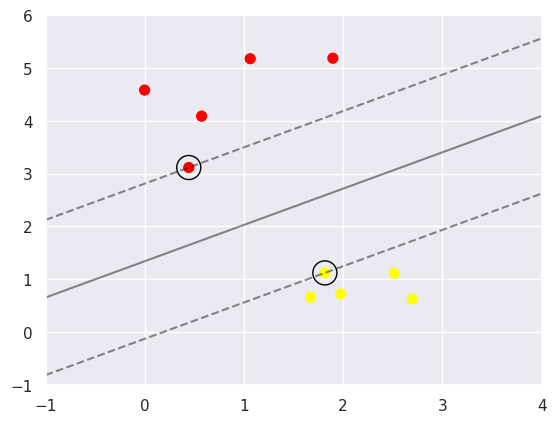

In [ ]:
from ipywidgets import interact, fixed
interact(plot_svm, N=[10, 200], ax=fixed(None));

SVM staje się niezwykle potężna, gdy jest połączona z jądrami. Wersję jądra widzieliśmy już wcześniej, w regresji funkcji bazowej w In Depth: Regresja liniowa. Tam rzutowaliśmy nasze dane na przestrzeń o wyższym wymiarze zdefiniowaną przez wielomiany i gaussowskie funkcje bazowe, a tym samym byliśmy w stanie dopasować się do nieliniowych relacji za pomocą liniowego klasyfikatora.

W modelach SVM możemy użyć wersji tego samego pomysłu. Aby zmotywować potrzebę stosowania jąder, przyjrzyjmy się pewnym danym, które nie są liniowo rozdzielne:

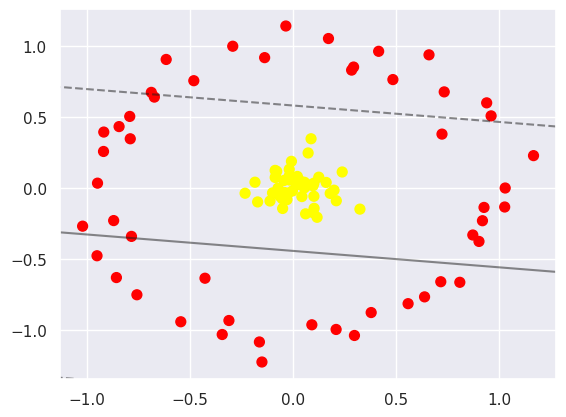

In [ ]:
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

clf = SVC(kernel='linear').fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf, plot_support=False);

Oczywiste jest, że żadna liniowa dyskryminacja nigdy nie będzie w stanie rozdzielić tych danych. Możemy jednak wyciągnąć wnioski z regresji funkcji bazowej w In Depth: Regresja liniowa i zastanowić się, w jaki sposób możemy rzutować dane na wyższy wymiar, tak aby separator liniowy był wystarczający. Na przykład, jedną prostą projekcją, której moglibyśmy użyć, byłoby obliczenie radialnej funkcji bazowej wyśrodkowanej na środkowej kępie:

In [ ]:
r = np.exp(-(X ** 2).sum(1))

Możemy wizualizować ten dodatkowy wymiar danych za pomocą trójwymiarowego wykresu - jeśli uruchomisz ten notatnik na żywo, będziesz mógł użyć suwaków do obracania wykresu:

interactive(children=(Dropdown(description='elev', options=(-90, 90), value=-90), IntSlider(value=30, descript…

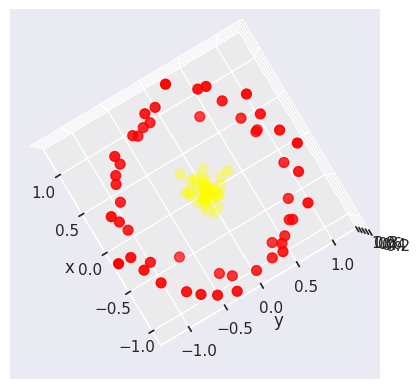

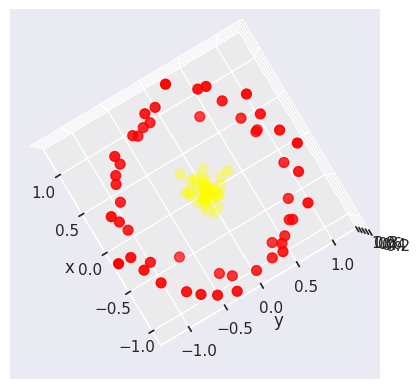

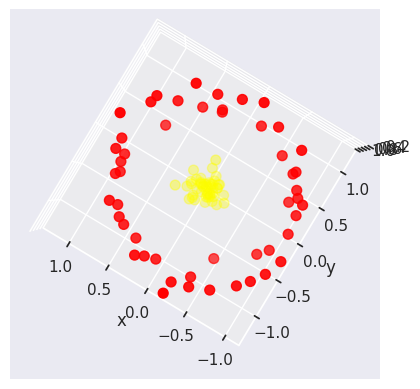

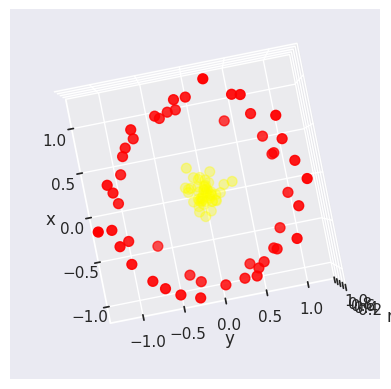

In [ ]:
from mpl_toolkits import mplot3d

def plot_3D(elev=30, azim=30, X=X, y=y):
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='autumn')
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('r')

interact(plot_3D, elev=[-90, 90], azip=(-180, 180),
         X=fixed(X), y=fixed(y));

Widzimy, że dzięki temu dodatkowemu wymiarowi dane stają się trywialnie liniowo rozdzielne, poprzez narysowanie płaszczyzny rozdzielającej na, powiedzmy, r=0,7.

Tutaj musieliśmy wybrać i starannie dostroić naszą projekcję: gdybyśmy nie wyśrodkowali naszej radialnej funkcji bazowej we właściwym miejscu, nie zobaczylibyśmy tak czystych, liniowo separowalnych wyników. Ogólnie rzecz biorąc, konieczność dokonania takiego wyboru stanowi problem: chcielibyśmy w jakiś sposób automatycznie znaleźć najlepsze funkcje bazowe do użycia.

Jedną ze strategii jest obliczenie funkcji bazowej wyśrodkowanej w każdym punkcie zbioru danych i pozwolenie algorytmowi SVM na przesianie wyników. Ten typ transformacji funkcji bazowej jest znany jako transformacja jądra, ponieważ opiera się na relacji podobieństwa (lub jądrze) między każdą parą punktów.

Potencjalnym problemem związanym z tą strategią - rzutowaniem N punktów na N wymiarów - jest to, że może ona stać się bardzo pracochłonna obliczeniowo, gdy N rośnie. Jednak ze względu na zgrabną małą procedurę znaną jako sztuczka jądra, dopasowanie do danych przekształconych przez jądro może być wykonane w sposób niejawny - to znaczy bez konieczności budowania pełnej N -wymiarowej reprezentacji projekcji jądra! Ta sztuczka z jądrem jest wbudowana w SVM i jest jednym z powodów, dla których metoda ta jest tak potężna.

W Scikit-Learn możemy zastosować SVM z kernelem, po prostu zmieniając nasze jądro liniowe na jądro RBF (radial basis function), używając hiperparametru modelu jądra:

In [ ]:
clf = SVC(kernel='rbf', C=1E6)
clf.fit(X, y)

SVC(C=1000000.0)

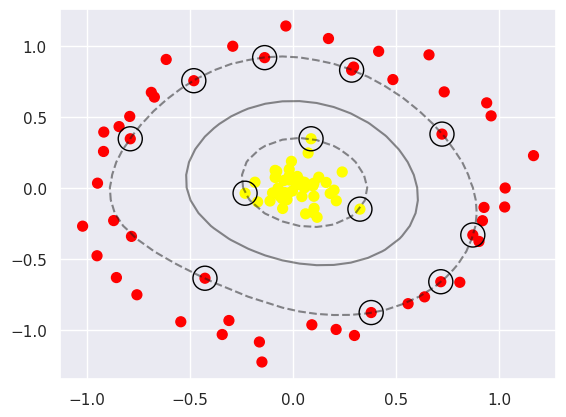

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=300, lw=1, facecolors='none');

Korzystając z tej kernelizowanej maszyny wektorów nośnych, uczymy się odpowiedniej nieliniowej granicy decyzyjnej. Ta strategia transformacji jądra jest często stosowana w uczeniu maszynowym do przekształcania szybkich metod liniowych w szybkie metody nieliniowe, szczególnie w przypadku modeli, w których można zastosować sztuczkę jądra

Nasza dotychczasowa dyskusja koncentrowała się na bardzo czystych zestawach danych, w których istnieje idealna granica decyzyjna. Ale co, jeśli dane w pewnym stopniu się pokrywają? Na przykład, możesz mieć takie dane:

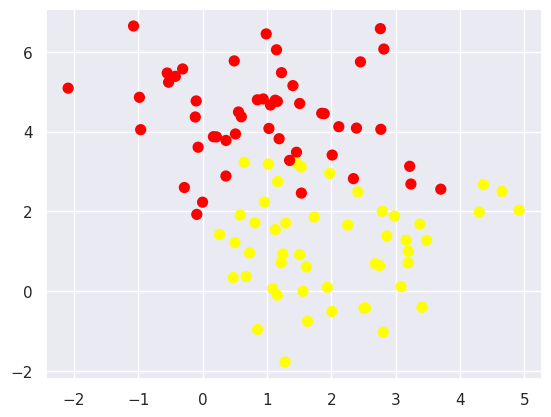

In [ ]:
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=1.2)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn');

Aby poradzić sobie z tym przypadkiem, implementacja SVM ma pewien współczynnik krówki, który „zmiękcza” margines: to znaczy, pozwala niektórym punktom wkraść się do marginesu, jeśli pozwala to na lepsze dopasowanie. Twardość marginesu jest kontrolowana przez parametr strojenia, najczęściej znany jako C . Dla bardzo dużego C , margines jest twardy, a punkty nie mogą w nim leżeć. Dla mniejszego C , margines jest bardziej miękki i może obejmować niektóre punkty.

Poniższy wykres przedstawia wizualny obraz tego, jak zmiana parametru C wpływa na ostateczne dopasowanie poprzez zmiękczenie marginesu:

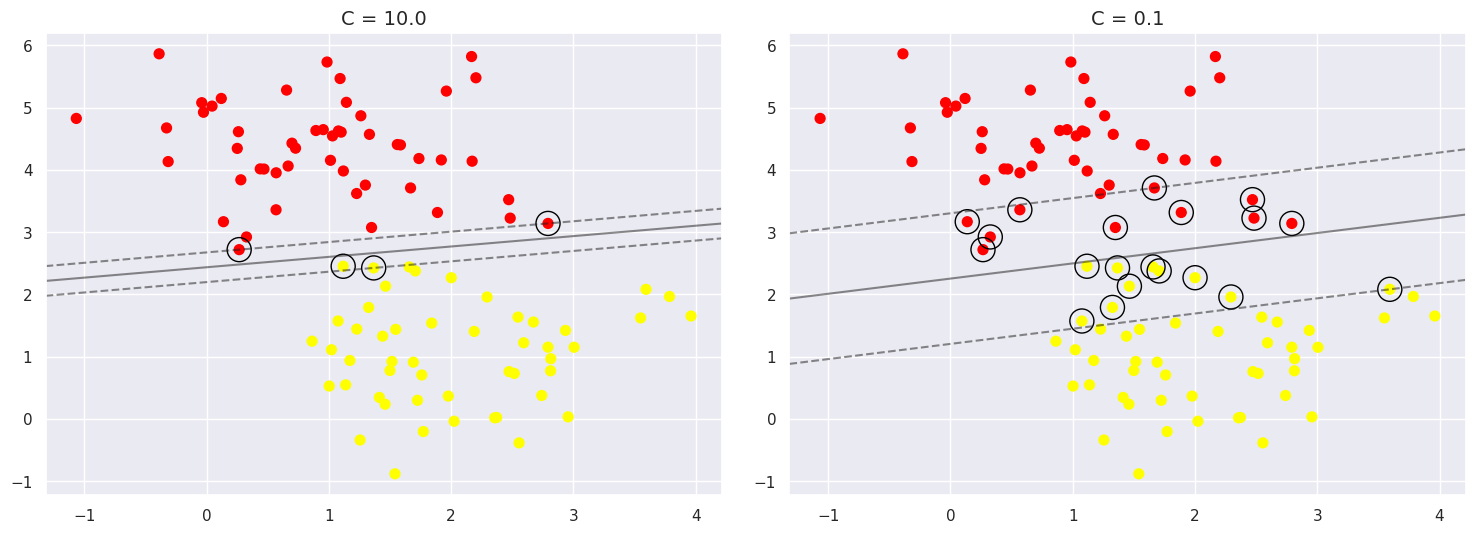

In [ ]:
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=0.8)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

for axi, C in zip(ax, [10.0, 0.1]):
    model = SVC(kernel='linear', C=C).fit(X, y)
    axi.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
    plot_svc_decision_function(model, axi)
    axi.scatter(model.support_vectors_[:, 0],
                model.support_vectors_[:, 1],
                s=300, lw=1, facecolors='none');
    axi.set_title('C = {0:.1f}'.format(C), size=14)

Optymalna wartość parametru C będzie zależeć od zbioru danych i powinna być dostrojona za pomocą walidacji krzyżowej lub podobnej procedury (patrz hiperparametry i walidacja modelu).

As an example of support vector machines in action, let's take a look at the facial recognition problem. We will use the Labeled Faces in the Wild dataset, which consists of several thousand collated photos of various public figures. A fetcher for the dataset is built into Scikit-Learn: